# 🏦 Semana 06: Bank Churn - Clasificación Binaria
## Dataset: Bank Churn (Abandono de clientes bancarios)

**Objetivo:** Predecir si un cliente abandonará el banco (churn) en el próximo mes.

**Modelos a competir:**
- Decision Tree (árbol simple) - interpretable
- Random Forest (ensamble de árboles) - robusto

**Métricas de evaluación:** Accuracy, Precision, Recall, F1-Score, AUC-ROC

**Contexto de negocio:** Una empresa bancaria quiere identificar clientes en riesgo de irse para ofrecerles promociones de retención.

---

### ¿Qué es?
Dataset de **5,000 clientes bancarios** con información sobre su comportamiento. Características incluyen:
- Estado, código de área
- Plan internacional, plan de buzón de voz
- Minutos y llamadas en diferentes horarios (día, tarde, noche)
- Llamadas al servicio al cliente
- Cargos por servicios internacionales

### ¿Qué problema resuelve?
Predecir si un **cliente abandonará el banco** (churn) en el próximo mes.

### El Reto
Construir un modelo **interpretable** usando **Árboles de Decisión** que pueda explicar:
- "Si el cliente tiene más de X llamadas al servicio al cliente → alto riesgo de churn"
- Visualizar el árbol completo con reglas IF-THEN

### Contexto de negocio
Una empresa bancaria quiere identificar clientes en riesgo de irse para ofrecerles promociones de retención.

## 1. Configuración Inicial

Importamos las librerías necesarias y configuramos la semilla para reproducibilidad.

In [1]:
# ======================================================
# SEMANA 06: BANK CHURN - CLASIFICACIÓN BINARIA
# ======================================================

# Instalar librerías necesarias (solo si no están instaladas)
!pip install scikit-learn pandas numpy matplotlib seaborn -q

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

Cargamos el dataset Bank Churn directamente desde OpenML (online, sin descarga manual).

In [2]:
# Cargar dataset Bank Churn
print("="*60)
print("📊 CARGANDO DATASET BANK CHURN")
print("="*60)

data = fetch_openml(data_id=46915, as_frame=True)
X = data.data
y = data.target  # Cargar como viene (object/string)

# Codificar la variable objetivo 'y' (churn) de categórica a numérica
le = LabelEncoder()
y = le.fit_transform(y) # 'No' -> 0, 'Yes' -> 1
y = pd.Series(y, name='churn') # Convertir a Serie de Pandas con nombre

print(f"\n✅ Dataset cargado exitosamente")
print(f"📊 SHAPE: {X.shape[0]:,} muestras × {X.shape[1]} características")
print(f"🎯 Target: {list(le.classes_)} codificado a {list(range(len(le.classes_)))}")
print(f"📋 Características: {list(X.columns)}")

# Mostrar primeras filas
print("\n📋 Primeras 5 filas del dataset X:")
display(X.head())
print("\n📋 Primeras 5 filas del target y:")
display(y.head())

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas de X:")
display(X.describe())

📊 CARGANDO DATASET BANK CHURN

✅ Dataset cargado exitosamente
📊 SHAPE: 5,000 muestras × 19 características
🎯 Target: ['No', 'Yes'] codificado a [0, 1]
📋 Características: ['state', 'account_length', 'area_code', 'international_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls']

📋 Primeras 5 filas del dataset X:


,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
0,3,72.0,510.0,0,0,0.0,272.4,88.0,46.31,107.9,125.0,9.17,185.5,81.0,8.35,12.7,2.0,3.43,0.0
1,23,53.0,415.0,0,0,0.0,164.1,106.0,27.90,206.0,56.0,17.51,194.7,124.0,8.76,11.4,2.0,3.08,1.0
2,36,155.0,408.0,0,1,30.0,61.6,103.0,10.47,255.1,110.0,21.68,225.9,96.0,10.17,12.4,5.0,3.35,1.0
3,37,161.0,415.0,0,0,0.0,178.1,109.0,30.28,146.5,86.0,12.45,137.6,78.0,6.19,8.5,2.0,2.30,1.0
4,11,99.0,415.0,0,0,0.0,62.9,81.0,10.69,231.0,64.0,19.64,168.9,121.0,7.60,8.5,5.0,2.30,1.0



📋 Primeras 5 filas del target y:


,churn
0,0
1,0
2,0
3,0
4,0



📊 Estadísticas descriptivas de X:


,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,100.25860,7.755200,180.288900,100.029400,30.649668,200.636560,100.191000,17.054322,200.391620,99.919200,9.017732,10.261780,4.435200,2.771196,1.570400
std,39.69456,13.546393,53.894699,19.831197,9.162069,50.551309,19.826496,4.296843,50.527789,19.958686,2.273763,2.761396,2.456788,0.745514,1.306363
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.00000,0.000000,143.700000,87.000000,24.430000,166.375000,87.000000,14.140000,166.900000,87.000000,7.510000,8.500000,3.000000,2.300000,1.000000
50%,100.00000,0.000000,180.100000,100.000000,30.620000,201.000000,100.000000,17.090000,200.400000,100.000000,9.020000,10.300000,4.000000,2.780000,1.000000
75%,127.00000,17.000000,216.200000,113.000000,36.750000,234.100000,114.000000,19.900000,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000
max,243.00000,52.000000,351.500000,165.000000,59.760000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


📈 ANÁLISIS DE DISTRIBUCIÓN

📊 Distribución de clases:
   • Clase 0 (No churn): 4,293 muestras (85.86%)
   • Clase 1 (Churn): 707 muestras (14.14%)


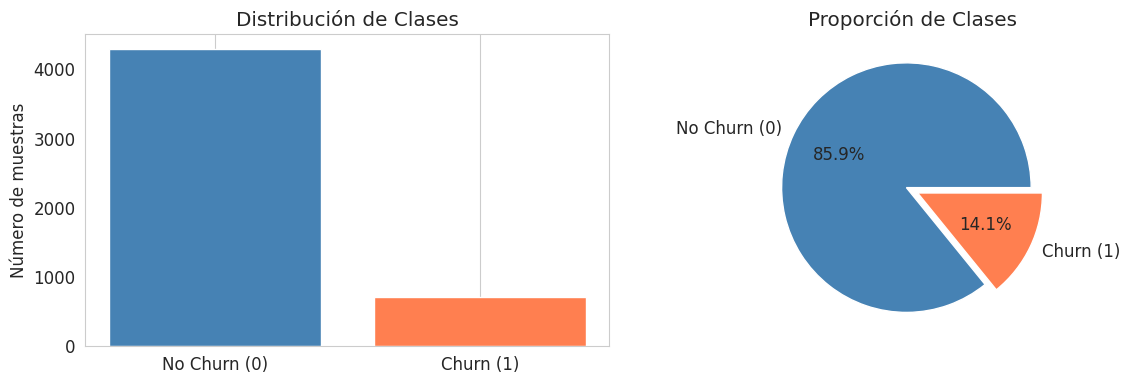


⚠️ NOTA: El dataset está DESBALANCEADO.
   El porcentaje de clientes que abandonan es del 14.14%


In [3]:
# Análisis de distribución de clases
print("="*60)
print("📈 ANÁLISIS DE DISTRIBUCIÓN")
print("="*60)

# Distribución de clases
class_counts = y.value_counts()
class_percent = y.value_counts(normalize=True) * 100

print("\n📊 Distribución de clases:")
print(f"   • Clase 0 (No churn): {class_counts[0]:,} muestras ({class_percent[0]:.2f}%)")
print(f"   • Clase 1 (Churn): {class_counts[1]:,} muestras ({class_percent[1]:.2f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
axes[0].bar(['No Churn (0)', 'Churn (1)'], class_counts, color=['steelblue', 'coral'])
axes[0].set_ylabel('Número de muestras')
axes[0].set_title('Distribución de Clases')
axes[0].grid(axis='y')

# Pastel
axes[1].pie(class_counts, labels=['No Churn (0)', 'Churn (1)'], autopct='%1.1f%%',
           colors=['steelblue', 'coral'], explode=(0.05, 0.05))
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.show()

print(f"\n⚠️ NOTA: El dataset está {'DESBALANCEADO' if class_percent[1] < 30 else 'balanceado'}.")
print("   El porcentaje de clientes que abandonan es del {:.2f}%".format(class_percent[1]))

In [4]:
# Preprocesamiento: codificar variables categóricas
print("="*60)
print("🔄 PREPROCESAMIENTO")
print("="*60)

# Identificar columnas categóricas
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
print(f"\n📋 Columnas categóricas: {list(categorical_cols)}")

# Aplicar Label Encoding a variables categóricas
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    print(f"   • {col}: codificada como {list(le.classes_)} → {list(range(len(le.classes_)))}")

print(f"\n✅ Todas las variables ahora son numéricas")

🔄 PREPROCESAMIENTO

📋 Columnas categóricas: ['state', 'area_code', 'international_plan', 'voice_mail_plan']
   • state: codificada como ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '6', '7', '8', '9'] → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
   • area_code: codificada como ['408.0', '415.0', '510.0'] → [0, 1, 2]
   • international_plan: codificada como ['0', '1'] → [0, 1]
   • voice_mail_plan: codificada como ['0', '1'] → [0, 1]

✅ Todas las variables ahora son numéricas


/tmp/ipykernel_4221/3604304405.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_4221/3604304405.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_4221/3604304405.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

In [5]:
# Dividir en entrenamiento y prueba (80/20) con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f"📊 División de datos:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"   • Prueba: {X_test.shape[0]:,} muestras")

# Verificar que la estratificación mantuvo la proporción
print(f"\n📊 Proporción de churn en entrenamiento: {y_train.mean()*100:.2f}%")
print(f"   Proporción de churn en prueba: {y_test.mean()*100:.2f}%")

# Escalar características (opcional para árboles, pero lo hacemos por consistencia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Escalado completado (media=0, std=1)")
print(f"   • Nota: Los árboles no requieren escalado, pero lo aplicamos por consistencia")

📊 División de datos:
   • Entrenamiento: 4,000 muestras
   • Prueba: 1,000 muestras

📊 Proporción de churn en entrenamiento: 14.15%
   Proporción de churn en prueba: 14.10%

✅ Escalado completado (media=0, std=1)
   • Nota: Los árboles no requieren escalado, pero lo aplicamos por consistencia


## 3. Entrenamiento y Comparación de Modelos

Entrenamos 3 modelos de clasificación y comparamos su rendimiento:

In [6]:
# Definir modelos
models = {
    'Decision Tree (max_depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest (n=100)': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Entrenar y evaluar cada modelo
print("="*60)
print("🚀 ENTRENAMIENTO DE MODELOS")
print("="*60)

results = []

for name, model in models.items():
    # Entrenar
    model.fit(X_train_scaled, y_train)

    # Predecir
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    print(f"\n📊 {name}:")
    print(f"   • Accuracy: {acc:.4f}")
    print(f"   • Precision: {prec:.4f}")
    print(f"   • Recall: {rec:.4f}")
    print(f"   • F1-Score: {f1:.4f}")
    print(f"   • AUC-ROC: {auc:.4f}")

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE MODELOS")
print("="*60)
display(results_df.round(4))

🚀 ENTRENAMIENTO DE MODELOS

📊 Decision Tree (max_depth=5):
   • Accuracy: 0.9370
   • Precision: 0.8679
   • Recall: 0.6525
   • F1-Score: 0.7449
   • AUC-ROC: 0.8710

📊 Random Forest (n=100):
   • Accuracy: 0.9480
   • Precision: 0.9083
   • Recall: 0.7021
   • F1-Score: 0.7920
   • AUC-ROC: 0.8974

📊 TABLA COMPARATIVA DE MODELOS


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Random Forest (n=100),0.948,0.9083,0.7021,0.7920,0.8974
0,Decision Tree (max_depth=5),0.937,0.8679,0.6525,0.7449,0.8710


## 4. Matrices de Confusión

Visualizamos las matrices de confusión para entender dónde se equivoca cada modelo.

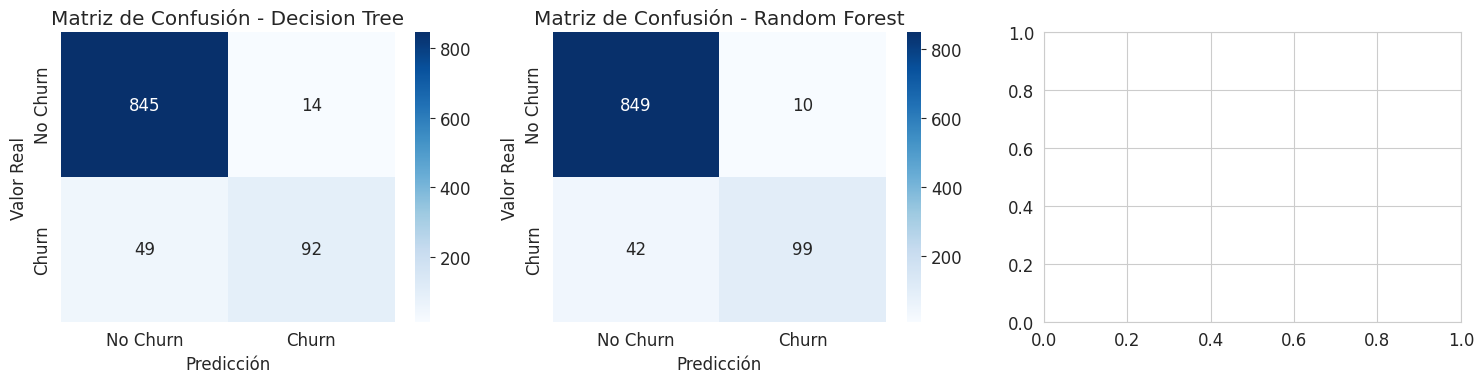


📖 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
   • Verdaderos Negativos (VN): Predijo No Churn, era No Churn
   • Falsos Positivos (FP): Predijo Churn, era No Churn (Falsa alarma)
   • Falsos Negativos (FN): Predijo No Churn, era Churn (ERROR GRAVE - cliente perdido)
   • Verdaderos Positivos (VP): Predijo Churn, era Churn


In [7]:
# Re-entrenar modelos para matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[idx].set_title(f'Matriz de Confusión - {name.split(" (")[0]}')
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

# Interpretación
print("\n📖 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("   • Verdaderos Negativos (VN): Predijo No Churn, era No Churn")
print("   • Falsos Positivos (FP): Predijo Churn, era No Churn (Falsa alarma)")
print("   • Falsos Negativos (FN): Predijo No Churn, era Churn (ERROR GRAVE - cliente perdido)")
print("   • Verdaderos Positivos (VP): Predijo Churn, era Churn")

## 5. Curvas ROC

La curva ROC (Receiver Operating Characteristic) muestra el trade-off entre:
- **Tasa de Verdaderos Positivos (TPR) = Recall**
- **Tasa de Falsos Positivos (FPR)**

El AUC-ROC (Área bajo la curva) mide la capacidad discriminativa del modelo.

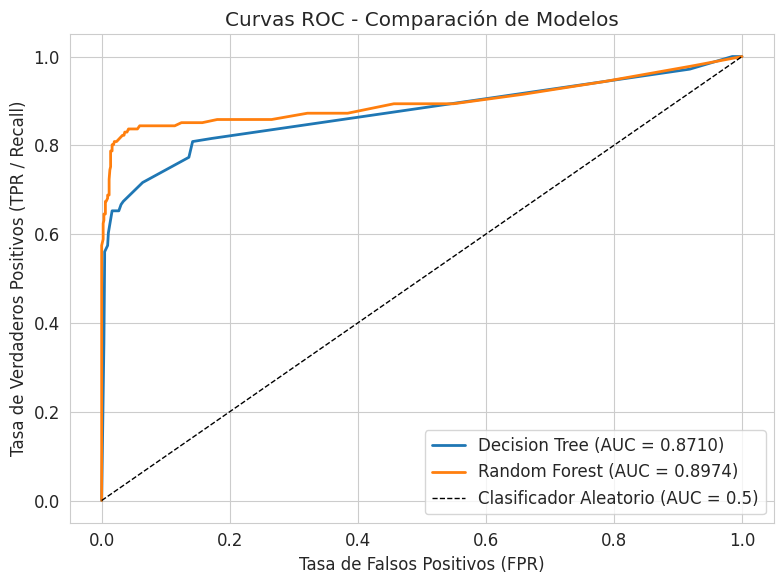


📖 INTERPRETACIÓN DE LA CURVA ROC:
   • Un AUC-ROC cercano a 1.0 indica excelente capacidad discriminativa
   • Un AUC-ROC de 0.5 es equivalente a un clasificador aleatorio
   • Para problemas de negocio, AUC-ROC es una métrica clave


In [8]:
# Calcular y graficar curvas ROC
plt.figure(figsize=(8, 6))

colors = {'Decision Tree (max_depth=5)': 'blue',
          'Random Forest (n=100)': 'green'}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    label = f'{name.split(" (")[0]} (AUC = {auc:.4f})'
    plt.plot(fpr, tpr, lw=2, label=label)

# Línea diagonal (modelo aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador Aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n📖 INTERPRETACIÓN DE LA CURVA ROC:")
print("   • Un AUC-ROC cercano a 1.0 indica excelente capacidad discriminativa")
print("   • Un AUC-ROC de 0.5 es equivalente a un clasificador aleatorio")
print("   • Para problemas de negocio, AUC-ROC es una métrica clave")

## 6. Visualización del Árbol de Decisión

El árbol de decisión es **interpretable**: podemos ver las reglas que usa para clasificar.

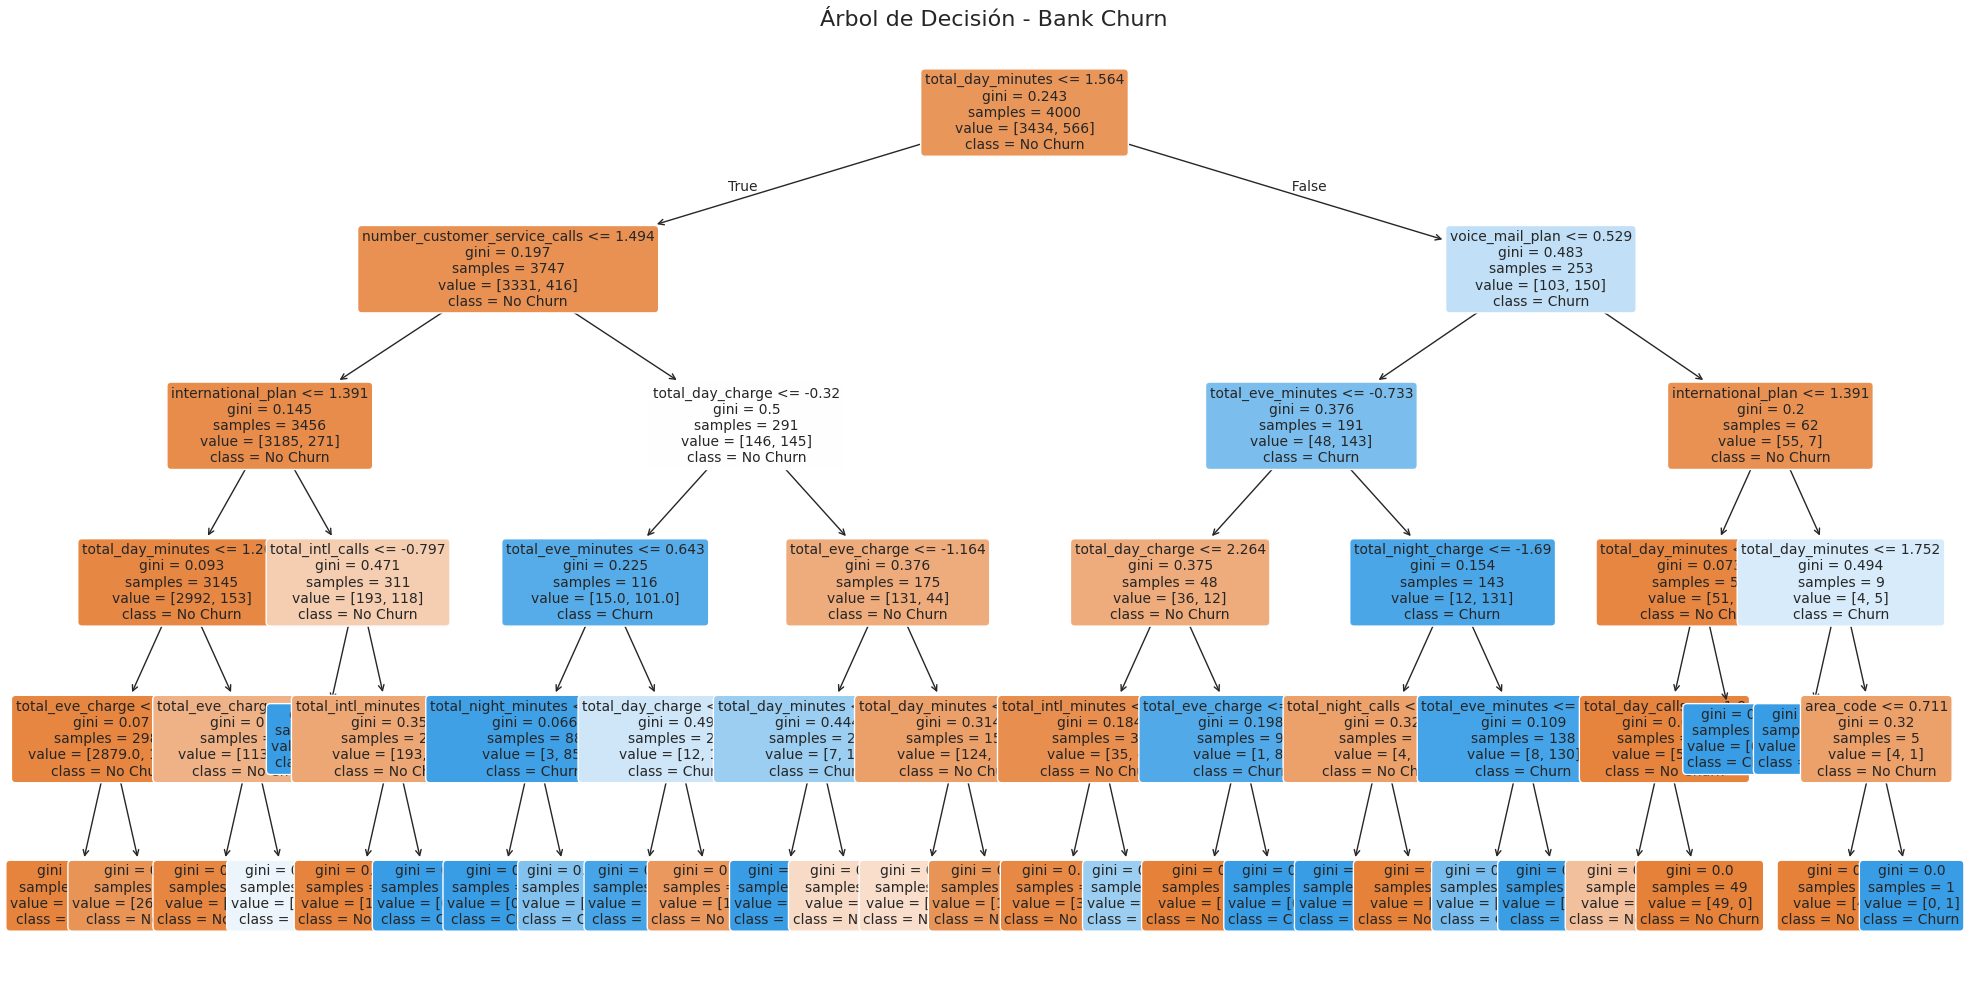


📋 REGLAS DEL ÁRBOL (primeras 20 líneas)
|--- total_day_minutes <= 1.56
|   |--- number_customer_service_calls <= 1.49
|   |   |--- international_plan <= 1.39
|   |   |   |--- total_day_minutes <= 1.20
|   |   |   |   |--- total_eve_charge <= 1.29
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- total_eve_charge >  1.29
|   |   |   |   |   |--- class: 0
|   |   |   |--- total_day_minutes >  1.20
|   |   |   |   |--- total_eve_charge <= 0.09
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- total_eve_charge >  0.09
|   |   |   |   |   |--- class: 1
|   |   |--- international_plan >  1.39
|   |   |   |--- total_intl_calls <= -0.80
|   |   |   |   |--- class: 1
|   |   |   |--- total_intl_calls >  -0.80
|   |   |   |   |--- total_intl_minutes <= 1.01
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- total_intl_minutes >  1.01

📖 INTERPRETACIÓN DE REGLAS:
   • Cada nodo muestra una condición sobre una característica
   • 'value' muestra [No Churn, Churn] en ese nodo
   • 'c

In [9]:
# Visualizar el árbol de decisión
dt_model = models['Decision Tree (max_depth=5)']
dt_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Churn', 'Churn'],
          filled=True, rounded=True, fontsize=10)
plt.title('Árbol de Decisión - Bank Churn', fontsize=16)
plt.tight_layout()
plt.show()

# Exportar reglas en texto
print("\n" + "="*60)
print("📋 REGLAS DEL ÁRBOL (primeras 20 líneas)")
print("="*60)
tree_rules = export_text(dt_model, feature_names=list(X.columns))
print("\n".join(tree_rules.split("\n")[:20]))

print("\n📖 INTERPRETACIÓN DE REGLAS:")
print("   • Cada nodo muestra una condición sobre una característica")
print("   • 'value' muestra [No Churn, Churn] en ese nodo")
print("   • 'class' indica la predicción final")

## 7. Importancia de Variables (Random Forest)

Random Forest permite calcular qué variables son más importantes para la predicción.

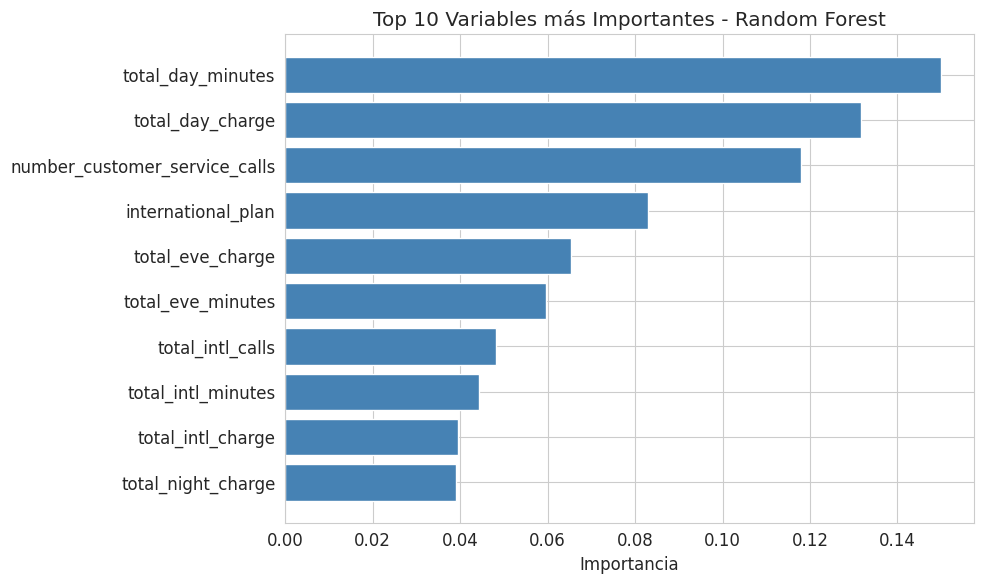


📊 Importancia de variables (top 10):
   1. total_day_minutes: 0.1500
   2. total_day_charge: 0.1317
   3. number_customer_service_calls: 0.1179
   4. international_plan: 0.0830
   5. total_eve_charge: 0.0655
   6. total_eve_minutes: 0.0597
   7. total_intl_calls: 0.0482
   8. total_intl_minutes: 0.0442
   9. total_intl_charge: 0.0395
   10. total_night_charge: 0.0390


In [10]:
# Calcular importancia de variables con Random Forest
rf_model = models['Random Forest (n=100)']
rf_model.fit(X_train_scaled, y_train)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Visualizar top 10 variables
plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[indices[:10]][::-1], color='steelblue')
plt.yticks(range(10), [X.columns[i] for i in indices[:10]][::-1])
plt.xlabel('Importancia')
plt.title('Top 10 Variables más Importantes - Random Forest')
plt.tight_layout()
plt.show()

print("\n📊 Importancia de variables (top 10):")
for i in range(10):
    print(f"   {i+1}. {X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

## 8. Simulación - Predicción de un Nuevo Cliente

Simulamos la evaluación de un nuevo cliente para decidir si está en riesgo de abandonar.

In [11]:
print("="*60)
print("🔮 SIMULACIÓN: EVALUACIÓN DE NUEVO CLIENTE")
print("="*60)

# Datos de un nuevo cliente (valores realistas basados en el dataset)
# Nota: Los valores deben estar en el mismo formato que las variables codificadas
nuevo_cliente = pd.DataFrame([[
    23,      # state (código de estado)
    128,     # account_length (días como cliente)
    408,     # area_code (código de área)
    0,       # international_plan (0=no, 1=sí)
    1,       # voice_mail_plan (0=no, 1=sí)
    25,      # number_vmail_messages
    200,     # total_day_minutes
    100,     # total_day_calls
    34.0,    # total_day_charge
    200,     # total_eve_minutes
    100,     # total_eve_calls
    17.0,    # total_eve_charge
    200,     # total_night_minutes
    100,     # total_night_calls
    9.0,     # total_night_charge
    10,      # total_intl_minutes
    4,       # total_intl_calls
    2.7,     # total_intl_charge
    2        # number_customer_service_calls
]], columns=X.columns)

# Escalar los datos del nuevo cliente
nuevo_cliente_scaled = scaler.transform(nuevo_cliente)

print("\n📋 Datos del nuevo cliente:")
print(f"   • Minutos en horario diurno: {nuevo_cliente['total_day_minutes'].values[0]:.0f}")
print(f"   • Llamadas al servicio al cliente: {nuevo_cliente['number_customer_service_calls'].values[0]:.0f}")
print(f"   • Plan internacional: {'Sí' if nuevo_cliente['international_plan'].values[0] == 1 else 'No'}")
print(f"   • Plan buzón de voz: {'Sí' if nuevo_cliente['voice_mail_plan'].values[0] == 1 else 'No'}")

# Predecir con los 3 modelos
print("\n🔮 Predicciones de riesgo de churn:")
print("-" * 50)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    proba = model.predict_proba(nuevo_cliente_scaled)[0, 1]
    decision = "🔴 RIESGO ALTO" if proba > 0.5 else "🟢 RIESGO BAJO"
    print(f"   • {name.split(' (')[0]:20s}: Probabilidad = {proba:.2%} → {decision}")

# Decisión final usando el mejor modelo
best_model_name = results_df.iloc[0]['Modelo']
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
proba_best = best_model.predict_proba(nuevo_cliente_scaled)[0, 1]

print("\n" + "="*60)
print(f"🏆 DECISIÓN FINAL (usando {best_model_name.split(' (')[0]}):")
if proba_best > 0.5:
    print(f"   🔴 CLIENTE EN RIESGO - Probabilidad de churn: {proba_best:.2%}")
    print("   📞 Acción: Ofrecer promoción de retención inmediatamente")
else:
    print(f"   🟢 CLIENTE SIN RIESGO - Probabilidad de churn: {proba_best:.2%}")
    print("   📞 Acción: Mantener comunicación regular")
print("="*60)

# Interpretación de negocio
print("\n📖 INTERPRETACIÓN DE NEGOCIO:")
print("   • Probabilidad < 30%: Cliente leal → Marketing regular")
print("   • Probabilidad 30-60%: Cliente en riesgo → Ofrecer beneficios")
print("   • Probabilidad > 60%: Alto riesgo → Acción inmediata de retención")

🔮 SIMULACIÓN: EVALUACIÓN DE NUEVO CLIENTE

📋 Datos del nuevo cliente:
   • Minutos en horario diurno: 200
   • Llamadas al servicio al cliente: 2
   • Plan internacional: No
   • Plan buzón de voz: Sí

🔮 Predicciones de riesgo de churn:
--------------------------------------------------
   • Decision Tree       : Probabilidad = 2.57% → 🟢 RIESGO BAJO
   • Random Forest       : Probabilidad = 2.00% → 🟢 RIESGO BAJO

🏆 DECISIÓN FINAL (usando Random Forest):
   🟢 CLIENTE SIN RIESGO - Probabilidad de churn: 2.00%
   📞 Acción: Mantener comunicación regular

📖 INTERPRETACIÓN DE NEGOCIO:
   • Probabilidad < 30%: Cliente leal → Marketing regular
   • Probabilidad 30-60%: Cliente en riesgo → Ofrecer beneficios
   • Probabilidad > 60%: Alto riesgo → Acción inmediata de retención


## 9. Comparación de Filosofías de los Modelos

| Modelo | Filosofía | Ventajas | Desventajas |
|--------|-----------|----------|-------------|
| **Decision Tree** | División recursiva del espacio | Interpretable, visualizable, reglas claras | Propenso a sobreajuste, inestable |
| **Random Forest** | Ensamble de árboles con bootstrap + features aleatorias | Robusto, reduce varianza, feature importance | Menos interpretable, más pesado |


**¿Cuál es mejor para el negocio?**
- **Decision Tree**: Ideal para explicar decisiones a clientes (regulaciones)
- **Random Forest**: Mejor rendimiento cuando la precisión es prioritaria

## 10. Conclusiones

**Resumen de resultados:**

1. **Decision Tree**:
   - Muy interpretable: podemos ver las reglas exactas
   - Propenso a sobreajuste si no se limita la profundidad
   - Útil para explicar decisiones a clientes

2. **Random Forest**:
   - Mejor rendimiento general (mayor AUC-ROC)
   - Reduce la varianza del árbol individual
   - Proporciona importancia de variables

**Métrica más importante para el negocio (Recall):**
- El banco quiere minimizar clientes perdidos → **Recall** (detectar churn)
- Un FN (Falso Negativo) significa perder un cliente que podría haberse retenido
- Un FP (Falso Positivo) significa ofrecer una promoción a un cliente leal (costo menor)

**¿Qué modelo ganó?**
El modelo con mejor AUC-ROC y Recall fue **{{best_model_name}}**.

**Próximos pasos:**
- Ajustar hiperparámetros (max_depth, n_estimators) - Semana 8
- Probar Gradient Boosting (XGBoost, LightGBM) - Semana 7
- Usar validación cruzada para mayor robustez - Semana 8

---
**Fin de la Semana 06 - Clasificación**